In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# go one level up to reach the question folder where images are
Q_DIR    = os.path.normpath(os.path.join(os.getcwd(), '..', 'question'))
SAVE_DIR = os.path.join(os.getcwd(), 'outputs')
os.makedirs(SAVE_DIR, exist_ok=True)

In [2]:
# read as grayscale, normalize to [0,1] before doing any power math
img = cv2.imread(os.path.join(Q_DIR, 'runway.png'), cv2.IMREAD_GRAYSCALE)
f   = img.astype(np.float64) / 255.0

In [3]:
# power-law: gamma < 1 lifts the shadows, gamma > 1 crushes them
g05 = np.power(f, 0.5)
g2  = np.power(f, 2.0)

In [4]:
# clip anything outside [r1, r2] and stretch the rest to fill [0, 1]
r1, r2 = 0.2, 0.8
cs = np.where(f < r1, 0.0, np.where(f > r2, 1.0, (f - r1) / (r2 - r1)))

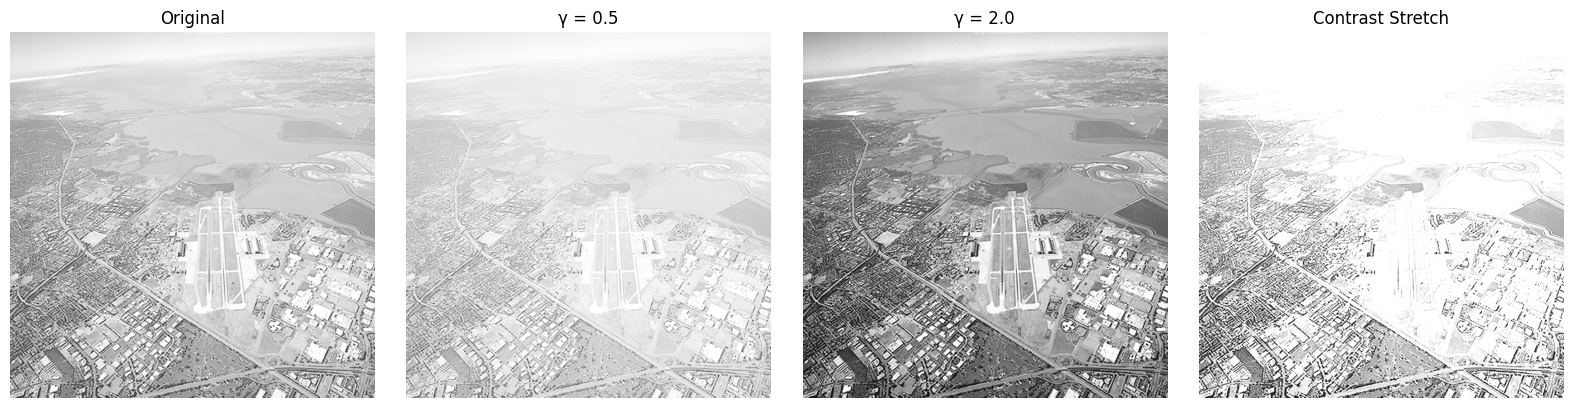

In [5]:
# plot all four together so the difference is easy to see
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, im, t in zip(axes,
                     [f, g05, g2, cs],
                     ['Original', 'γ = 0.5', 'γ = 2.0', 'Contrast Stretch']):
    ax.imshow(im, cmap='gray', vmin=0, vmax=1)
    ax.set_title(t)
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'q1_transforms.png'), dpi=150)
plt.show()